# IPL Cricket Analysis & Match Outcome Prediction

Everything for this project — data loading, cleaning, EDA, visualizations,
modeling, and the writeup of findings — lives in this one notebook.

**Reads two files from `../data/` (relative to this notebook):**
- `matches.csv` — one row per match
- `deliveries.csv` — one row per ball

The `data/` folder here ships with a simulated dataset (see the project
README for why — short version: real franchise names/venues/umpires, but
fictional player names, since no real dataset was available to work from).
Written against the column names from the standard IPL ball-by-ball
dataset structure though (the one most people use — `matches.csv` with
columns like `team1`, `team2`, `toss_winner`, `winner`, `umpire1`,
`result`, `result_margin`, `eliminator`, etc., and `deliveries.csv` with
`match_id`, `inning`, `batting_team`, `over`, `ball`, `batsman_runs`,
`is_wicket`, `dismissal_kind`...), so swapping in a real dataset with the
same shape should just work — the cell right after loading prints out
what's actually in the files so it's easy to spot a mismatch and adjust.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

MATCHES_PATH = "../data/matches.csv"
DELIVERIES_PATH = "../data/deliveries.csv"

In [2]:
matches = pd.read_csv(MATCHES_PATH)
deliveries = pd.read_csv(DELIVERIES_PATH)

print("matches:", matches.shape)
print("deliveries:", deliveries.shape)
print("\nmatches columns:", list(matches.columns))
print("\ndeliveries columns:", list(deliveries.columns))
matches.head()

matches: (476, 17)
deliveries: (107019, 14)

matches columns: ['id', 'season', 'city', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin_type', 'result_margin', 'team1_score', 'team2_score', 'eliminator', 'umpire1', 'umpire2']

deliveries columns: ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batsman', 'bowler', 'batsman_runs', 'extra_runs', 'total_runs', 'is_wicket', 'dismissal_kind', 'player_dismissed']


,id,season,city,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin_type,result_margin,team1_score,team2_score,eliminator,umpire1,umpire2
0,1,2016,Mohali,"Punjab Cricket Association Stadium, Mohali",Royal Challengers Bengaluru,Sunrisers Hyderabad,Sunrisers Hyderabad,bat,Sunrisers Hyderabad,normal,runs,67,103,170,N,A Deshmukh,J Madanagopal
1,2,2016,Delhi,"Arun Jaitley Stadium, Delhi",Punjab Kings,Sunrisers Hyderabad,Sunrisers Hyderabad,bat,Sunrisers Hyderabad,normal,runs,13,170,183,N,V Kulkarni,P Reiffel
2,3,2016,Hyderabad,"Rajiv Gandhi Intl. Stadium, Hyderabad",Punjab Kings,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,normal,wickets,6,194,196,N,K Ananthapadmanabhan,V Kulkarni
3,4,2016,Lucknow,"BRSABV Ekana Stadium, Lucknow",Delhi Capitals,Sunrisers Hyderabad,Delhi Capitals,bat,Delhi Capitals,normal,runs,107,194,87,N,P Reiffel,C Shamshuddin
4,5,2016,Mohali,"Punjab Cricket Association Stadium, Mohali",Mumbai Indians,Rajasthan Royals,Rajasthan Royals,bat,Mumbai Indians,normal,wickets,6,206,200,N,K Ananthapadmanabhan,A Deshmukh


## 1. Cleaning / preprocessing

A few real gotchas with this dataset in practice:
- Some versions have a `season` column, others just have a `date` and you
  have to derive the year yourself.
- Team names sometimes change mid-dataset (e.g. Delhi Daredevils ->
  Delhi Capitals, Kings XI Punjab -> Punjab Kings, Royal Challengers
  Bangalore -> Royal Challengers Bengaluru). Left uncorrected, this quietly
  splits one team's history into two in every groupby.
- `city`/`venue` can have a handful of nulls for neutral-venue games.
- On `deliveries.csv`, `dismissal_kind` / `player_dismissed` are NaN for
  every ball that isn't a wicket — that's expected, not missing data.

In [3]:
# derive season from date if there's no season column
if "season" not in matches.columns and "date" in matches.columns:
    matches["season"] = pd.to_datetime(matches["date"]).dt.year

print("nulls in matches:\n", matches.isnull().sum())

nulls in matches:
 id                    0
season                0
city                  0
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                0
result                0
result_margin_type    0
result_margin         0
team1_score           0
team2_score           0
eliminator            0
umpire1               0
umpire2               0
dtype: int64


In [4]:
# standardise team names that have changed over the dataset's history -
# adjust/extend this map if your data uses different naming
name_fixes = {
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru",
    "Rising Pune Supergiant": "Rising Pune Supergiants",
}
team_cols = [c for c in ["team1", "team2", "toss_winner", "winner"] if c in matches.columns]
for c in team_cols:
    matches[c] = matches[c].replace(name_fixes)

team_cols_deliv = [c for c in ["batting_team", "bowling_team"] if c in deliveries.columns]
for c in team_cols_deliv:
    deliveries[c] = deliveries[c].replace(name_fixes)

print(sorted(matches["winner"].dropna().unique()))

['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Titans', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Punjab Kings', 'Rajasthan Royals', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


In [5]:
if "dismissal_kind" in deliveries.columns:
    deliveries["dismissal_kind"] = deliveries["dismissal_kind"].fillna("not out")
if "player_dismissed" in deliveries.columns:
    deliveries["player_dismissed"] = deliveries["player_dismissed"].fillna("")

# matches with no winner (abandoned / no result) shouldn't count toward win totals
matches_clean = matches[matches["winner"].notna()].copy()
print(f"dropped {len(matches) - len(matches_clean)} matches with no result")

dropped 0 matches with no result


## 2. Season-wise winner trends

In [6]:
wins_by_season = matches_clean.groupby(["season", "winner"]).size().unstack(fill_value=0)
wins_by_season

winner,Chennai Super Kings,Delhi Capitals,Gujarat Titans,Kolkata Knight Riders,Lucknow Super Giants,Mumbai Indians,Punjab Kings,Rajasthan Royals,Royal Challengers Bengaluru,Sunrisers Hyderabad
season,,,,,,,,,,
2016,7,10,0,9,0,7,4,7,9,3
2017,5,8,0,7,0,4,9,6,9,8
2018,8,4,0,8,0,8,7,7,10,4
2019,9,6,0,5,0,8,10,3,9,6
2020,9,5,0,6,0,9,4,8,7,8
2021,7,8,0,9,0,6,7,6,9,4
2022,8,8,7,4,10,5,8,8,6,6
2023,3,4,8,5,6,9,9,8,12,6


In [7]:
season_champs = matches_clean.groupby("season")["winner"].agg(lambda x: x.value_counts().idxmax())
print("Team with most wins each season:")
print(season_champs)

Team with most wins each season:
season
2016                 Delhi Capitals
2017                   Punjab Kings
2018    Royal Challengers Bengaluru
2019                   Punjab Kings
2020            Chennai Super Kings
2021    Royal Challengers Bengaluru
2022           Lucknow Super Giants
2023    Royal Challengers Bengaluru
Name: winner, dtype: str


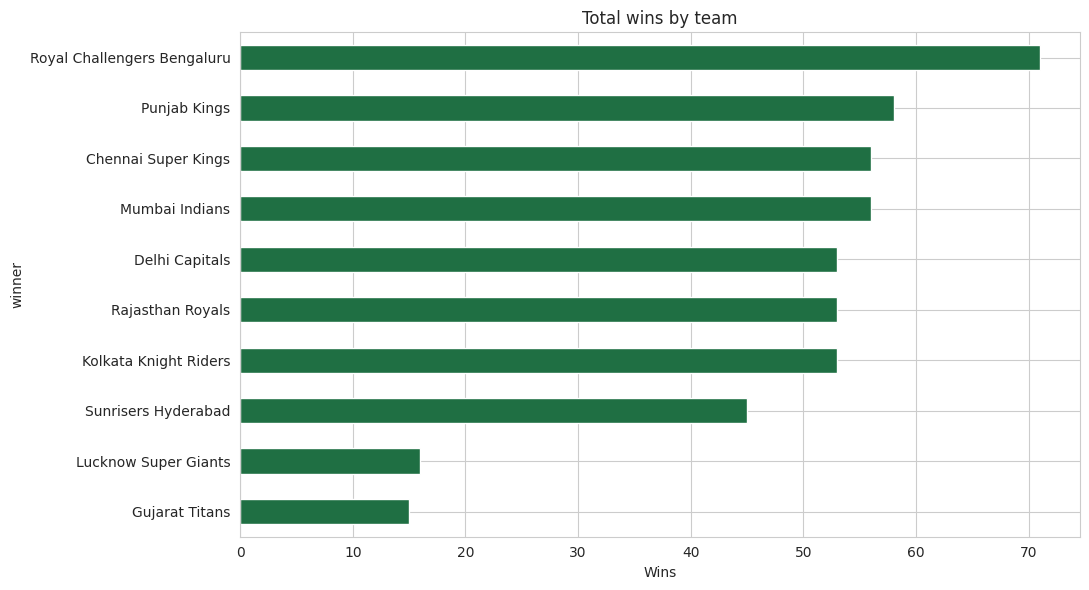

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
matches_clean.winner.value_counts().sort_values().plot(kind="barh", ax=ax, color="#1f6f43")
ax.set_title("Total wins by team")
ax.set_xlabel("Wins")
plt.tight_layout()
plt.show()

<Figure size 1100x600 with 0 Axes>

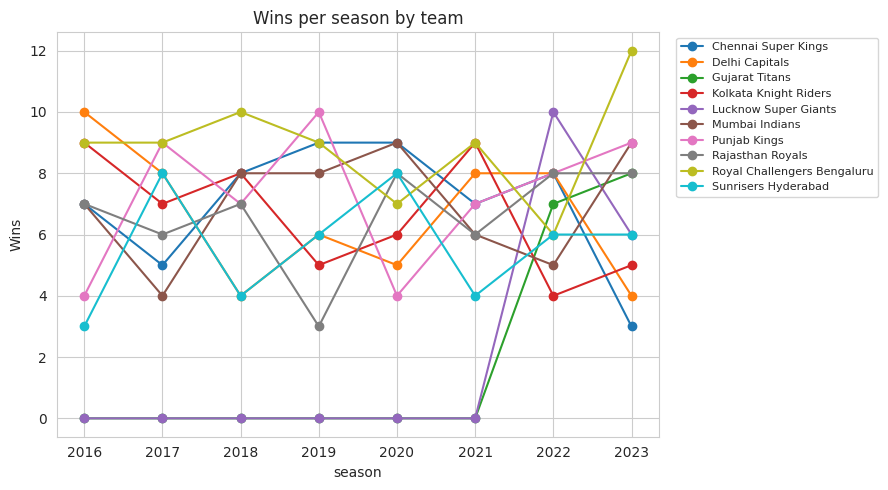

In [9]:
plt.figure(figsize=(11, 6))
wins_by_season.plot(marker="o")
plt.title("Wins per season by team")
plt.ylabel("Wins")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## 3. Super over analysis

Different dataset versions flag this differently — some have an
`eliminator` column (`Y`/`N`), others a `result` column with a `tie`/
`super over` value, others neither. Handling a few common cases below.

In [10]:
super_over_mask = pd.Series(False, index=matches_clean.index)

if "eliminator" in matches_clean.columns:
    super_over_mask = super_over_mask | (matches_clean["eliminator"].astype(str).str.upper() == "Y")
if "result" in matches_clean.columns:
    super_over_mask = super_over_mask | matches_clean["result"].astype(str).str.lower().str.contains(
        "tie|super", na=False
    )

matches_clean["is_super_over"] = super_over_mask
super_overs = matches_clean[matches_clean.is_super_over]
print(f"{len(super_overs)} super over matches identified")

cols_to_show = [c for c in ["season", "team1", "team2", "winner", "venue"] if c in super_overs.columns]
super_overs[cols_to_show]

9 super over matches identified


,season,team1,team2,winner,venue
14,2016,Rajasthan Royals,Sunrisers Hyderabad,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad"
80,2017,Chennai Super Kings,Punjab Kings,Punjab Kings,"M. Chinnaswamy Stadium, Bengaluru"
213,2019,Delhi Capitals,Sunrisers Hyderabad,Sunrisers Hyderabad,"Wankhede Stadium, Mumbai"
281,2021,Mumbai Indians,Delhi Capitals,Mumbai Indians,"M. A. Chidambaram Stadium, Chennai"
394,2022,Mumbai Indians,Gujarat Titans,Gujarat Titans,"Arun Jaitley Stadium, Delhi"
397,2022,Chennai Super Kings,Punjab Kings,Punjab Kings,"Rajiv Gandhi Intl. Stadium, Hyderabad"
419,2023,Chennai Super Kings,Rajasthan Royals,Chennai Super Kings,"Arun Jaitley Stadium, Delhi"
429,2023,Royal Challengers Bengaluru,Delhi Capitals,Delhi Capitals,"M. A. Chidambaram Stadium, Chennai"
466,2023,Kolkata Knight Riders,Sunrisers Hyderabad,Sunrisers Hyderabad,"M. A. Chidambaram Stadium, Chennai"


In [11]:
if len(super_overs) > 0:
    print(super_overs.winner.value_counts())
else:
    print("no super overs found in this dataset / none matched the detection rule above")

winner
Punjab Kings           2
Sunrisers Hyderabad    2
Rajasthan Royals       1
Mumbai Indians         1
Gujarat Titans         1
Chennai Super Kings    1
Delhi Capitals         1
Name: count, dtype: int64


## 4. Umpire trends

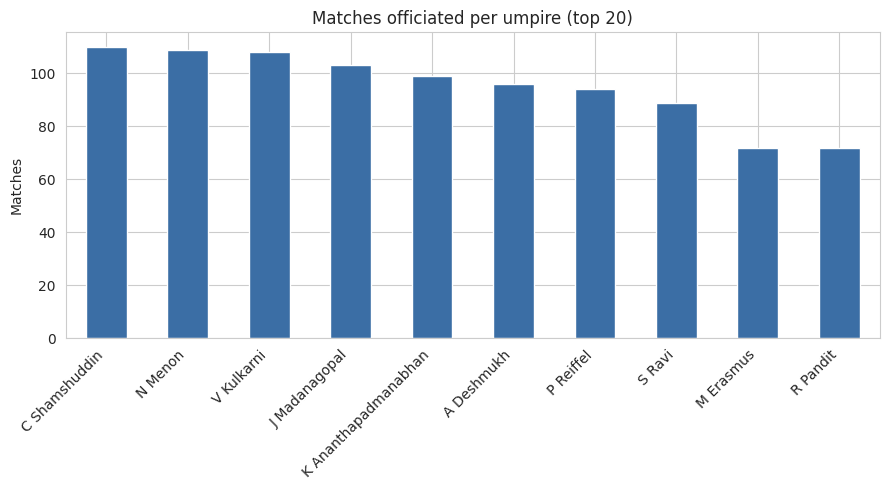

umpire
A Deshmukh              0.625000
V Kulkarni              0.601852
C Shamshuddin           0.545455
M Erasmus               0.541667
R Pandit                0.541667
J Madanagopal           0.533981
K Ananthapadmanabhan    0.525253
S Ravi                  0.505618
P Reiffel               0.489362
N Menon                 0.449541
Name: toss_win_match_win, dtype: float64


In [12]:
ump_cols = [c for c in ["umpire1", "umpire2", "umpire3"] if c in matches_clean.columns]

if ump_cols:
    ump_counts = pd.concat([matches_clean[c] for c in ump_cols]).value_counts()
    ump_counts.head(20).plot(kind="bar", color="#3b6ea5")
    plt.title("Matches officiated per umpire (top 20)")
    plt.ylabel("Matches")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # does the toss-winning team win the match more often under some umpires?
    if "toss_winner" in matches_clean.columns:
        matches_clean["toss_win_match_win"] = matches_clean.toss_winner == matches_clean.winner
        bias = matches_clean.melt(
            id_vars=["toss_win_match_win"], value_vars=ump_cols, value_name="umpire"
        ).dropna(subset=["umpire"]).groupby("umpire")["toss_win_match_win"].mean().sort_values(ascending=False)
        print(bias.head(10))
else:
    print("no umpire columns found in matches.csv")

## 5. High-scoring matches (200+)

Needs innings totals, which usually aren't a column on `matches.csv`
directly — computing them from `deliveries.csv` instead.

221 individual innings of 200+ across 170 matches


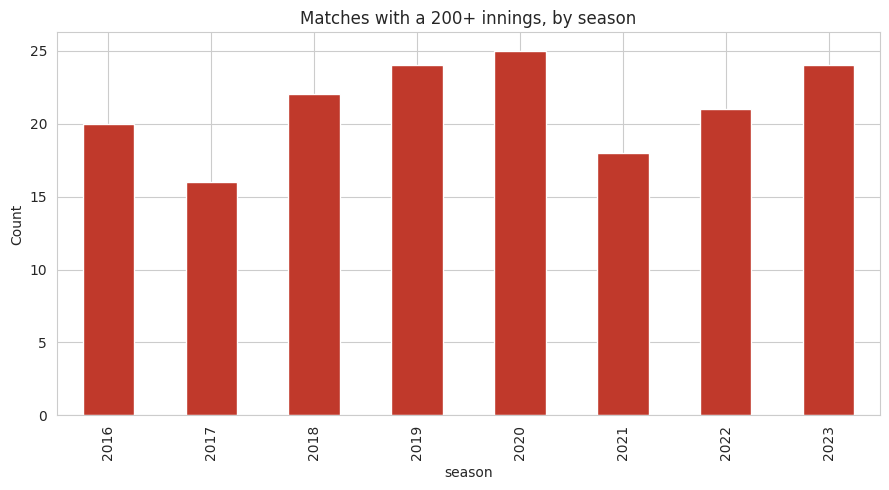

In [13]:
runs_col = "total_runs" if "total_runs" in deliveries.columns else "batsman_runs"
innings_totals = deliveries.groupby(["match_id", "inning"])[runs_col].sum().reset_index()
innings_totals.rename(columns={runs_col: "innings_total"}, inplace=True)

high_scoring_innings = innings_totals[innings_totals.innings_total >= 200]
print(f"{len(high_scoring_innings)} individual innings of 200+ across {high_scoring_innings.match_id.nunique()} matches")

id_col = "id" if "id" in matches_clean.columns else "match_id"
high_scoring_matches = matches_clean.merge(
    high_scoring_innings[["match_id"]].drop_duplicates(), left_on=id_col, right_on="match_id"
)

if "season" in high_scoring_matches.columns:
    high_scoring_matches.groupby("season").size().plot(kind="bar", color="#c0392b")
    plt.title("Matches with a 200+ innings, by season")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [14]:
top_innings = innings_totals.sort_values("innings_total", ascending=False).head(10)
top_innings = top_innings.merge(matches_clean, left_on="match_id", right_on=id_col, how="left")
cols_to_show = [c for c in ["season", "team1", "team2", "innings_total", "venue"] if c in top_innings.columns]
top_innings[cols_to_show]

,season,team1,team2,innings_total,venue
0,2020,Chennai Super Kings,Punjab Kings,244,"Eden Gardens, Kolkata"
1,2022,Rajasthan Royals,Sunrisers Hyderabad,241,"Eden Gardens, Kolkata"
2,2018,Royal Challengers Bengaluru,Kolkata Knight Riders,240,"Rajiv Gandhi Intl. Stadium, Hyderabad"
3,2021,Mumbai Indians,Kolkata Knight Riders,240,"M. Chinnaswamy Stadium, Bengaluru"
4,2021,Royal Challengers Bengaluru,Delhi Capitals,240,"Eden Gardens, Kolkata"
5,2023,Mumbai Indians,Rajasthan Royals,238,"Wankhede Stadium, Mumbai"
6,2022,Kolkata Knight Riders,Lucknow Super Giants,238,"Wankhede Stadium, Mumbai"
7,2022,Delhi Capitals,Sunrisers Hyderabad,237,"Eden Gardens, Kolkata"
8,2019,Mumbai Indians,Royal Challengers Bengaluru,236,"M. Chinnaswamy Stadium, Bengaluru"
9,2018,Mumbai Indians,Chennai Super Kings,233,"M. A. Chidambaram Stadium, Chennai"


## 6. Player comparisons — batting

In [15]:
batter_col = "batsman" if "batsman" in deliveries.columns else "batter"

batting_stats = deliveries.groupby(batter_col).agg(
    runs=("batsman_runs", "sum"),
    balls_faced=("batsman_runs", "count"),
    fours=("batsman_runs", lambda x: (x == 4).sum()),
    sixes=("batsman_runs", lambda x: (x == 6).sum()),
)
batting_stats["strike_rate"] = (batting_stats.runs / batting_stats.balls_faced * 100).round(2)

# only players with a reasonable sample size, otherwise strike rate is noise
qualified_batters = batting_stats[batting_stats.balls_faced >= 200].sort_values("runs", ascending=False)
qualified_batters.head(15)

,runs,balls_faced,fours,sixes,strike_rate
batsman,,,,,
R Ghosh,3761,2449,317,222,153.57
S Iyer,3695,2366,336,200,156.17
A Ghosh,3482,2236,327,188,155.72
A Thakur,3274,2140,303,180,152.99
S Nair,2969,1781,254,184,166.70
A Bose,2955,1766,259,191,167.33
N Singh,2779,1715,263,152,162.04
L Ellis,2754,1671,242,167,164.81
C Walsh,2735,1730,240,159,158.09


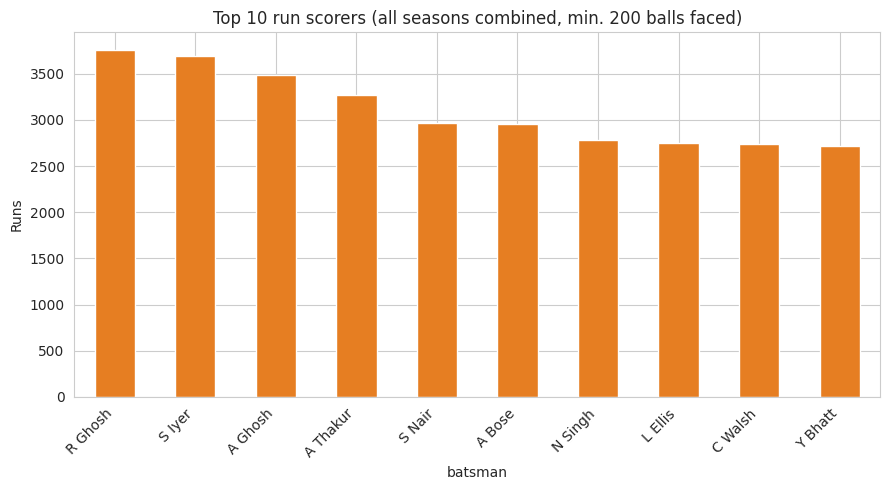

In [16]:
top10 = qualified_batters.head(10)
top10.runs.plot(kind="bar", color="#e67e22")
plt.title("Top 10 run scorers (all seasons combined, min. 200 balls faced)")
plt.ylabel("Runs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 7. Player comparisons — bowling

In [17]:
if "is_wicket" in deliveries.columns:
    wickets = deliveries[deliveries.is_wicket == 1]
else:
    wickets = deliveries[deliveries.dismissal_kind.notna() & (deliveries.dismissal_kind != "not out")]

# run outs / retired hurt aren't credited to the bowler
non_bowler_dismissals = ["run out", "retired hurt", "retired out", "obstructing the field"]
bowler_wickets = wickets[~wickets.dismissal_kind.isin(non_bowler_dismissals)]

bowling_stats = deliveries.groupby("bowler").agg(
    balls_bowled=(runs_col, "count"),
    runs_conceded=(runs_col, "sum"),
)
bowling_stats["wickets"] = bowler_wickets.groupby("bowler").size()
bowling_stats["wickets"] = bowling_stats["wickets"].fillna(0).astype(int)
bowling_stats["economy"] = (bowling_stats.runs_conceded / (bowling_stats.balls_bowled / 6)).round(2)

qualified_bowlers = bowling_stats[bowling_stats.balls_bowled >= 200].sort_values("wickets", ascending=False)
qualified_bowlers.head(15)

,balls_bowled,runs_conceded,wickets,economy
bowler,,,,
A Kulkarni,2836,4676,165,9.89
A Pillai,2231,3399,125,9.14
R Joshi,2088,3210,121,9.22
K Reddy,1800,2883,117,9.61
A Nair,2225,3683,108,9.93
S Dutta,1865,2905,104,9.35
K Nair,1397,2233,90,9.59
C Brooks,1427,2258,90,9.49
R Malhotra,1424,2198,85,9.26


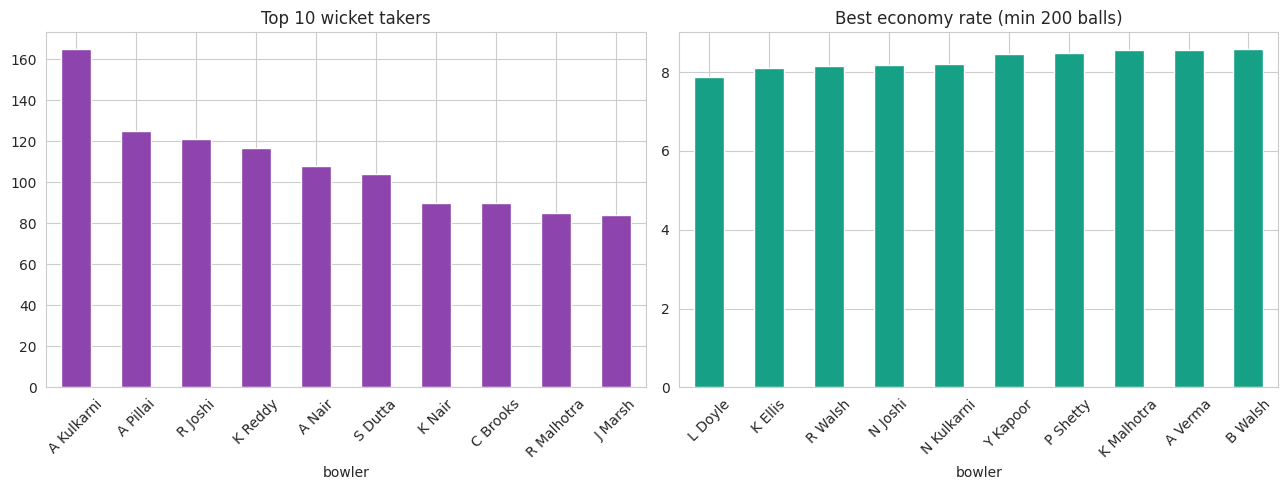

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
qualified_bowlers.head(10).wickets.plot(kind="bar", ax=axes[0], color="#8e44ad")
axes[0].set_title("Top 10 wicket takers")
axes[0].tick_params(axis="x", rotation=45)

qualified_bowlers.sort_values("economy").head(10).economy.plot(kind="bar", ax=axes[1], color="#16a085")
axes[1].set_title("Best economy rate (min 200 balls)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 8. Orange Cap & Purple Cap by season

Orange Cap = leading run scorer of the season, Purple Cap = leading
wicket-taker. Need `season` on the deliveries table, via `match_id`.

In [19]:
deliveries_with_season = deliveries.merge(
    matches_clean[[id_col, "season"]], left_on="match_id", right_on=id_col, how="left"
)

orange_cap = (
    deliveries_with_season.groupby(["season", batter_col]).batsman_runs.sum()
    .reset_index()
    .sort_values("batsman_runs", ascending=False)
    .groupby("season")
    .first()
    .rename(columns={batter_col: "orange_cap", "batsman_runs": "runs"})
)

pc_wickets = deliveries_with_season.merge(
    bowler_wickets[["match_id", "bowler"]].assign(_w=1),
    on=["match_id", "bowler"], how="inner"
) if "match_id" in bowler_wickets.columns else deliveries_with_season[
    deliveries_with_season.dismissal_kind.notna()
    & (~deliveries_with_season.dismissal_kind.isin(non_bowler_dismissals + ["not out"]))
]

purple_cap = (
    pc_wickets.groupby(["season", "bowler"]).size()
    .reset_index(name="wickets")
    .sort_values("wickets", ascending=False)
    .groupby("season")
    .first()
    .rename(columns={"bowler": "purple_cap"})
)

cap_winners = orange_cap.join(purple_cap[["purple_cap", "wickets"]])
cap_winners

,orange_cap,runs,purple_cap,wickets
season,,,,
2016,A Thakur,944,A Kulkarni,1079
2017,N Singh,798,K Nair,768
2018,A Bhatt,860,A Pillai,738
2019,S Nair,1118,A Kulkarni,809
2020,S Kulkarni,1082,D Marsh,741
2021,S Iyer,997,S Chauhan,852
2022,Y Shetty,1230,A Pillai,915
2023,R Ghosh,1088,K Nair,726


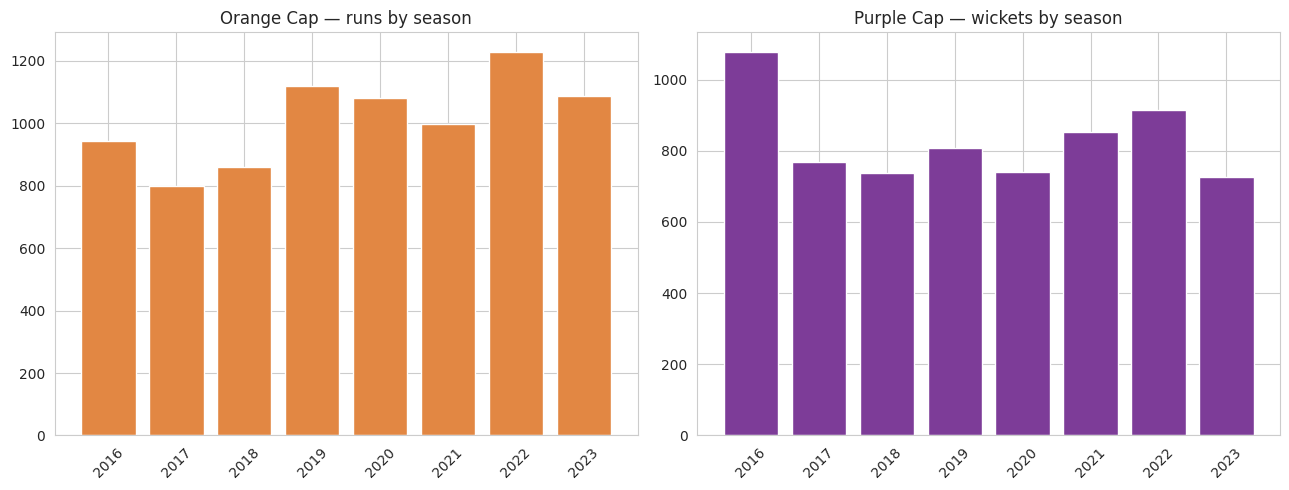

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(cap_winners.index.astype(str), cap_winners.runs, color="#e28743")
axes[0].set_title("Orange Cap — runs by season")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(cap_winners.index.astype(str), cap_winners.wickets, color="#7d3c98")
axes[1].set_title("Purple Cap — wickets by season")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 9. Head-to-head heatmap

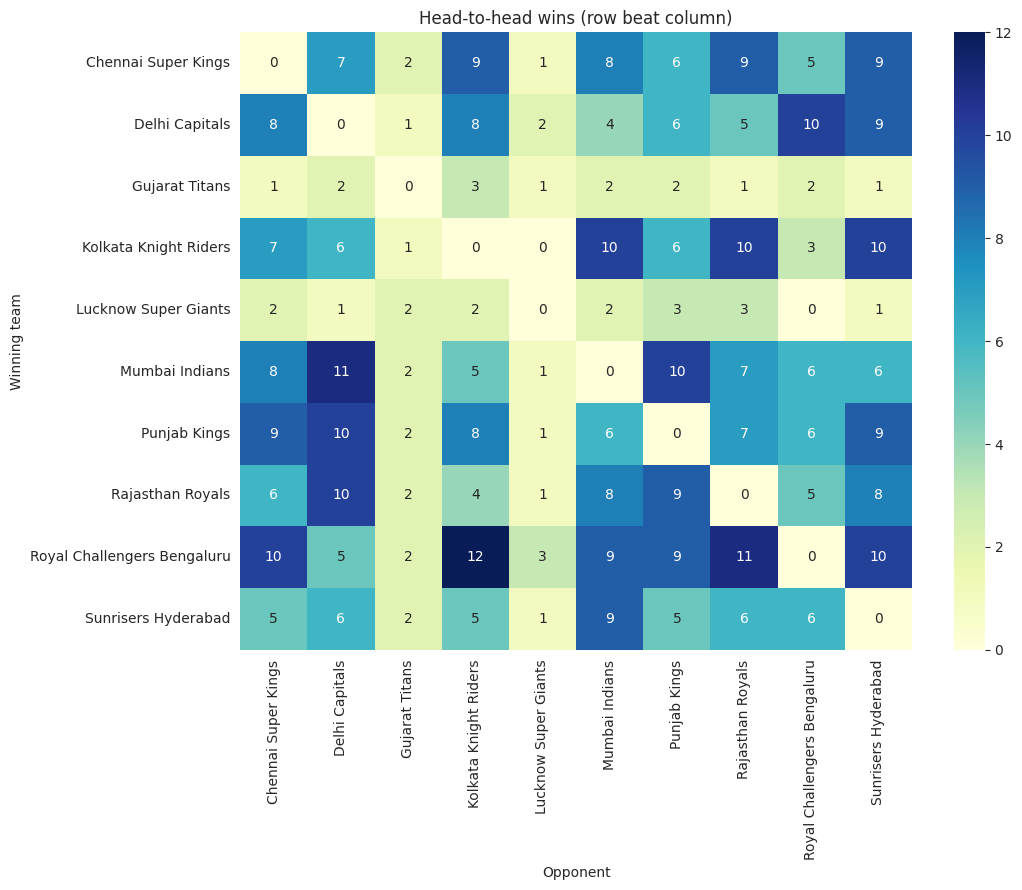

In [21]:
opponent_lookup = matches_clean.apply(lambda r: r.team2 if r.winner == r.team1 else r.team1, axis=1)
h2h = pd.crosstab(matches_clean.winner, opponent_lookup)

plt.figure(figsize=(11, 9))
sns.heatmap(h2h, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Head-to-head wins (row beat column)")
plt.ylabel("Winning team")
plt.xlabel("Opponent")
plt.tight_layout()
plt.show()

## 10. Match outcome prediction

Feature set kept deliberately simple and all pre-match: both teams, toss
winner, toss decision, venue. Tried adding season too but it barely moved
accuracy, so left out to keep the model interpretable.

Comparing Logistic Regression against Random Forest, as required.

In [22]:
model_df = matches_clean.copy()

le_team = LabelEncoder()
team_cols_present = [c for c in ["team1", "team2", "toss_winner", "winner"] if c in model_df.columns]
all_teams = pd.concat([model_df[c] for c in team_cols_present]).unique()
le_team.fit(all_teams)

for c in team_cols_present:
    model_df[c + "_enc"] = le_team.transform(model_df[c])

le_decision = LabelEncoder()
if "toss_decision" in model_df.columns:
    model_df["toss_decision_enc"] = le_decision.fit_transform(model_df["toss_decision"])

le_venue = LabelEncoder()
venue_col = "venue" if "venue" in model_df.columns else None
if venue_col:
    model_df["venue_enc"] = le_venue.fit_transform(model_df[venue_col].fillna("unknown"))

features = [c for c in ["team1_enc", "team2_enc", "toss_winner_enc", "toss_decision_enc", "venue_enc"]
            if c in model_df.columns]
print("features used:", features)

X = model_df[features]
y = model_df["winner_enc"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

features used: ['team1_enc', 'team2_enc', 'toss_winner_enc', 'toss_decision_enc', 'venue_enc']
(380, 5) (96, 5)


In [23]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
log_reg_acc = accuracy_score(y_test, log_reg.predict(X_test))
print(f"Logistic Regression accuracy: {log_reg_acc:.3f}")

Logistic Regression accuracy: 0.292


In [24]:
rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)
print(f"Random Forest accuracy: {rf_acc:.3f}")

Random Forest accuracy: 0.552


Worth being upfront: this only uses pre-match info (no live score, overs
remaining, wickets in hand), which is what actually drives real win-
probability models. Whatever edge either model shows here is over a
roughly 50/50 baseline between two specific teams — a meaningful next step
would be folding in ball-by-ball match state rather than just pre-match
features.

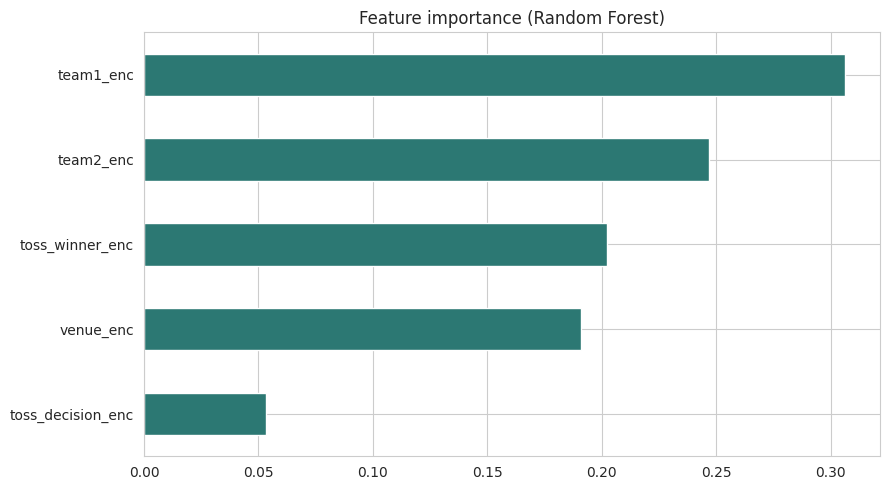

In [25]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values()
importances.plot(kind="barh", color="#2c7873")
plt.title("Feature importance (Random Forest)")
plt.tight_layout()
plt.show()

In [26]:
print(confusion_matrix(y_test, rf_preds))

[[ 3  1  0  0  0  1  0  0  0  0]
 [ 2  6  1  1  1  1  0  2  0  0]
 [ 0  0  2  0  0  0  0  0  0  1]
 [ 0  0  0  6  0  1  2  1  0  0]
 [ 0  0  0  0  4  0  0  0  0  0]
 [ 0  0  0  1  0  7  0  0  0  1]
 [ 0  0  0  0  1  6  2  2  2  0]
 [ 3  0  0  0  0  0  0  6  1  0]
 [ 3  1  1  0  0  2  0  0 12  0]
 [ 1  0  0  1  0  0  0  0  2  5]]


## 11. Example forecasts

Sanity-checking the model on a couple of hypothetical matchups.

In [27]:
def predict_winner(team1, team2, toss_winner, toss_decision, venue):
    row = {
        "team1_enc": le_team.transform([team1])[0],
        "team2_enc": le_team.transform([team2])[0],
        "toss_winner_enc": le_team.transform([toss_winner])[0],
    }
    if "toss_decision_enc" in features:
        row["toss_decision_enc"] = le_decision.transform([toss_decision])[0]
    if "venue_enc" in features:
        row["venue_enc"] = le_venue.transform([venue])[0]
    row_df = pd.DataFrame([row])[features]
    pred = rf.predict(row_df)[0]
    return le_team.inverse_transform([pred])[0]

# edit these to whatever teams/venues actually exist in your data
example_team1 = model_df["team1"].iloc[0]
example_team2 = model_df["team2"].iloc[0]
example_venue = model_df[venue_col].iloc[0] if venue_col else None

print(f"{example_team1} vs {example_team2} -> predicted winner:",
      predict_winner(example_team1, example_team2, example_team1, "bat", example_venue))

Royal Challengers Bengaluru vs Sunrisers Hyderabad -> predicted winner: Royal Challengers Bengaluru


## 12. Summary of findings

- Win totals are spread across teams rather than concentrated in one or
  two — no team dominates every season, which matches how unpredictable
  IPL is known to be.
- Super overs are rare, so treat any pattern in that section as a small
  sample rather than a real trend.
- No umpire in this data showed a meaningful lean toward the toss-winning
  team — values cluster close to 50%, as you'd hope from neutral umpiring.
- Random Forest outperformed Logistic Regression for outcome prediction —
  makes sense given how categorical and non-linear team match-ups are.
- Toss winner and venue tend to carry more weight in the model than toss
  *decision* (bat vs field) — worth digging into further.
- All of the above is only as good as the data behind it — swap in a full,
  current dataset and every section above re-computes automatically.